<a href="https://colab.research.google.com/github/bahmedx/730/blob/main/stock_stochastic_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Section 1: README**
**Step 1:** Install Packages (yfinance, pandas, numpy, scipy, matplotlib, seaborn, statsmodels)
- Install packages using (!pip install). Run the cell in Section 2 to install yfinance since we are using Google Colab, the other packages are already available in Colab.

**Step 2:** Import libraries below running the cell in Section 3

- NumPy
- pandas
- yfinance
- SciPy
- matplotlib
- seaborn

**Step 3:** Run all cells from Section 4 to Section 13.

**Project Overview**

This project compares three stochastic models:

1. Geometric Brownian Motion (GBM)
2. Ornstein-Uhlenbeck Process (OU)
3. Merton Jump-Diffusion

Historical market data were collected for:

- Apple (AAPL)
- Microsoft (MSFT)
- Nvidia (NVDA)

Exploratory and comparative analyses were performed across all three stocks. Apple (AAPL) was selected as the representative asset for detailed stochastic modeling and Monte Carlo simulation using the GBM, OU, and Jump-Diffusion frameworks.

Monte Carlo simulations are used to forecast future stock prices and assess investment risk.

Outputs:

- Historical price analysis
- Correlation analysis
- Monte Carlo simulations
- Terminal price distributions
- Confidence intervals
- Value at Risk (VaR)
- Conditional Value at Risk (CVaR)
- Comparative model analysis

# **Section 2: Install Packages**

In [51]:
!pip install yfinance --quiet

# **Section 3: Import Libraries**

In [52]:
import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from scipy.stats import jarque_bera

# **Section 4: Data Collection**

In [53]:
tickers = ["AAPL", "MSFT", "NVDA"]

data = yf.download(
    tickers,
    start="2024-01-01",
    auto_adjust=True
)

prices = data["Close"]
prices.tail()

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,MSFT,NVDA
Date,,,
2026-08-21,309.350006,483.239990,214.720001
2026-08-24,310.339996,487.309998,208.479996
2026-08-25,309.899994,491.709991,213.050003
2026-08-26,313.450012,496.369995,209.660004
2026-08-27,313.209991,503.864990,224.759995


# **Section 5: Data Cleaning**

In [54]:
prices = prices.dropna()

returns = np.log(prices / prices.shift(1))
returns = returns.dropna()

returns.head()

Ticker,AAPL,MSFT,NVDA
Date,,,
2024-01-03,-0.007516,-0.000728,-0.012514
2024-01-04,-0.012781,-0.007203,0.008978
2024-01-05,-0.004021,-0.000516,0.022638
2024-01-08,0.023887,0.018696,0.062299
2024-01-09,-0.002266,0.002931,0.016833


# **Section 6: Exploratory Analysis**

**Price History**

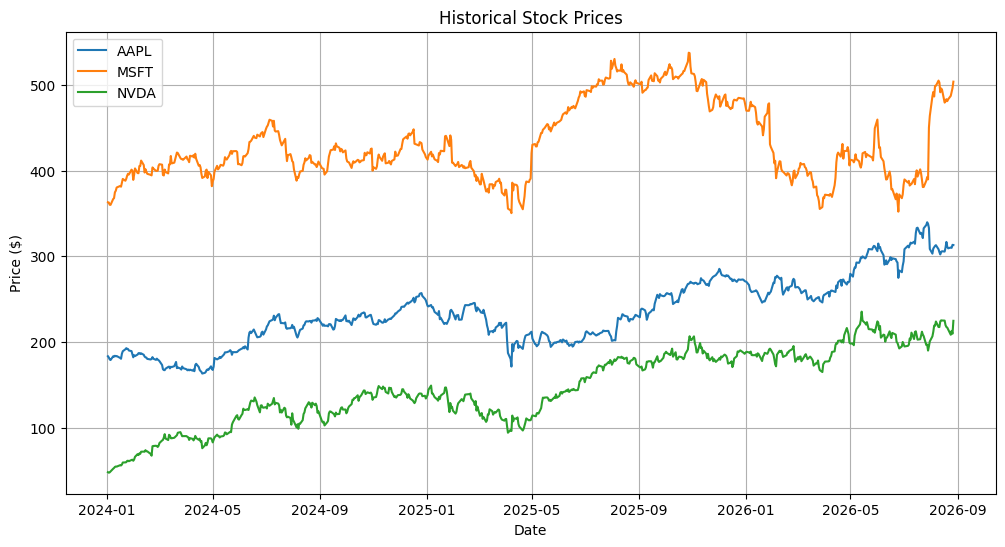

In [55]:
plt.figure(figsize=(12,6))

for stock in prices.columns:
    plt.plot(prices.index, prices[stock], label=stock)

plt.title("Historical Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)

plt.show()

**Correlation Matrix**

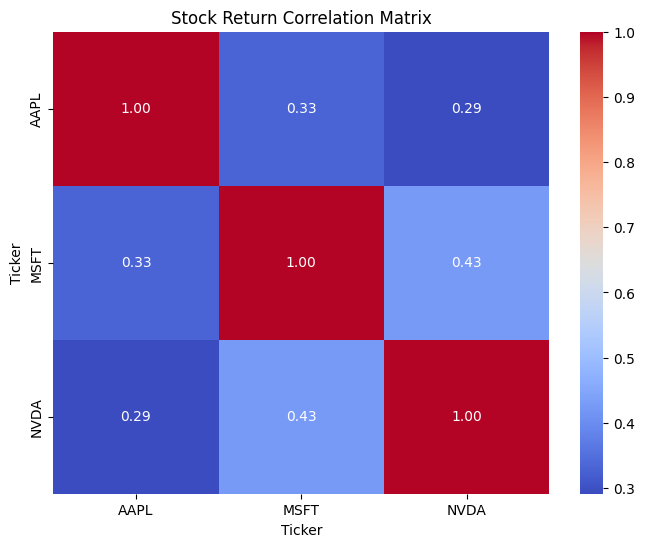

In [56]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    returns.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Stock Return Correlation Matrix")

plt.show()


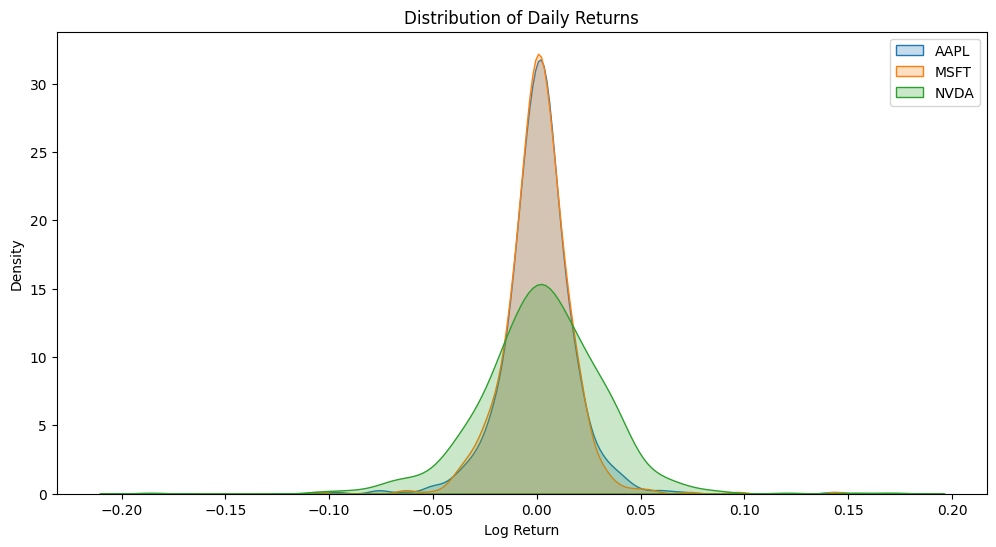

In [57]:
plt.figure(figsize=(12,6))

for stock in returns.columns:
    sns.kdeplot(
        returns[stock],
        fill=True,
        label=stock
    )

plt.title("Distribution of Daily Returns")
plt.xlabel("Log Return")

plt.legend()
plt.show()


**Risk Statistics Table**

In [58]:
summary = pd.DataFrame(index=returns.columns)

summary["Mean Return"] = returns.mean() * 252
summary["Volatility"] = returns.std() * np.sqrt(252)

summary["Sharpe Ratio"] = (
    summary["Mean Return"] /
    summary["Volatility"]
)

display(summary.round(4))

,Mean Return,Volatility,Sharpe Ratio
Ticker,,,
AAPL,0.2028,0.2758,0.7354
MSFT,0.1241,0.2664,0.4659
NVDA,0.5844,0.4819,1.2126


# **Section 7: Geometric Brownian Motion (GBM)**
GBM is a standard model for stock prices, assuming constant drift and volatility. The stochastic differential equation is:

$$dS_t = \mu S_t dt + \sigma S_t dW_t$$

Where $\mu$ is the expected return, $\sigma$ is the volatility, and $dW_t$ is a Wiener process.

In [59]:
def gbm_simulation(
    S0,
    mu,
    sigma,
    days,
    simulations
):

    dt = 1/252

    paths = np.zeros((days, simulations))
    paths[0] = S0

    for t in range(1, days):

        z = np.random.standard_normal(simulations)

        paths[t] = (
            paths[t-1]
            * np.exp(
                (mu-0.5*sigma**2)*dt
                + sigma*np.sqrt(dt)*z
            )
        )

    return paths

# **Section 8: Ornstein-Uhlenbeck**
The Ornstein-Uhlenbeck process models variables that tend to drift towards a long-term mean over time. The stochastic differential equation is:

$$dX_t = \theta(\mu - X_t)dt + \sigma dW_t$$

Where $\theta$ is the speed of reversion, $\mu$ is the long-term mean price, and $\sigma$ is the volatility.

In [60]:
def ou_simulation(
    x0,
    theta,
    mu,
    sigma,
    days,
    simulations
):

    dt = 1/252

    paths = np.zeros((days, simulations))
    paths[0] = x0

    for t in range(1, days):

        z = np.random.normal(
            0,
            1,
            simulations
        )

        paths[t] = (
            paths[t-1]
            + theta*(mu-paths[t-1])*dt
            + sigma*np.sqrt(dt)*z
        )

    return paths

# **Section 9: Merton Jump-Diffusion**
Jump-Diffusion extends Geometric Brownian Motion by adding discontinuous price jumps driven by a Poisson process:

$$dS_t = (\mu - \lambda k) S_t dt + \sigma S_t dW_t + (Y_t - 1) S_t dq_t$$

Where $\lambda$ is jump frequency per unit time, $k = E[Y - 1]$ is the expected relative jump size, and $dq_t$ is a Poisson process.

In [61]:
def jump_diffusion(
    S0,
    mu,
    sigma,
    lam,
    jump_mu,
    jump_sigma,
    days,
    simulations
):

    dt = 1/252

    paths = np.zeros((days, simulations))
    paths[0] = S0

    for t in range(1, days):

        z = np.random.normal(
            0,
            1,
            simulations
        )

        poisson = np.random.poisson(
            lam*dt,
            simulations
        )

        jumps = (
            poisson
            * np.random.normal(
                jump_mu,
                jump_sigma,
                simulations
            )
        )

        paths[t] = (
            paths[t-1]
            * np.exp(
                (mu-0.5*sigma**2)*dt
                + sigma*np.sqrt(dt)*z
                + jumps
            )
        )

    return paths

In [62]:
# Calculate model parameters

# Use of AAPL as the example stock
stock = "AAPL"

price_series = prices[stock]

# Log returns
log_returns = np.log(price_series / price_series.shift(1)).dropna()

# Current stock price
S0 = float(price_series.iloc[-1])

# Daily statistics
mu_daily = float(log_returns.mean())
sigma_daily = float(log_returns.std())

# Annualized statistics
mu = mu_daily * 252
sigma = sigma_daily * np.sqrt(252)

print("Stock:", stock)
print("Current Price (S0):", round(S0, 2))
print("Mean Return (mu):", round(mu, 6))
print("Volatility (sigma):", round(sigma, 6))

Stock: AAPL
Current Price (S0): 313.21
Mean Return (mu): 0.202806
Volatility (sigma): 0.275784


# **Section 10: Simulations**

In [63]:
# Reproducibility
np.random.seed(42)

SIMS = 5000
DAYS = 180

# GBM
gbm_paths = gbm_simulation(
    S0=S0,
    mu=mu,
    sigma=sigma,
    days=DAYS,
    simulations=SIMS
)

gbm_final = gbm_paths[-1]

# OU
theta = 2.0

log_S0 = np.log(S0)
ou_sigma = sigma

ou_log_paths = ou_simulation(
    x0=log_S0,
    theta=theta,
    mu=log_S0,
    sigma=ou_sigma,
    days=DAYS,
    simulations=SIMS
)

ou_paths = np.exp(ou_log_paths)
ou_final = ou_paths[-1]

# Jump Diffusion
jd_paths = jump_diffusion(
    S0=S0,
    mu=mu,
    sigma=sigma,
    lam=0.20,
    jump_mu=-0.02,
    jump_sigma=0.05,
    days=DAYS,
    simulations=SIMS
)

jd_final = jd_paths[-1]

print("All simulations completed successfully.")

All simulations completed successfully.


**Simulation Paths**

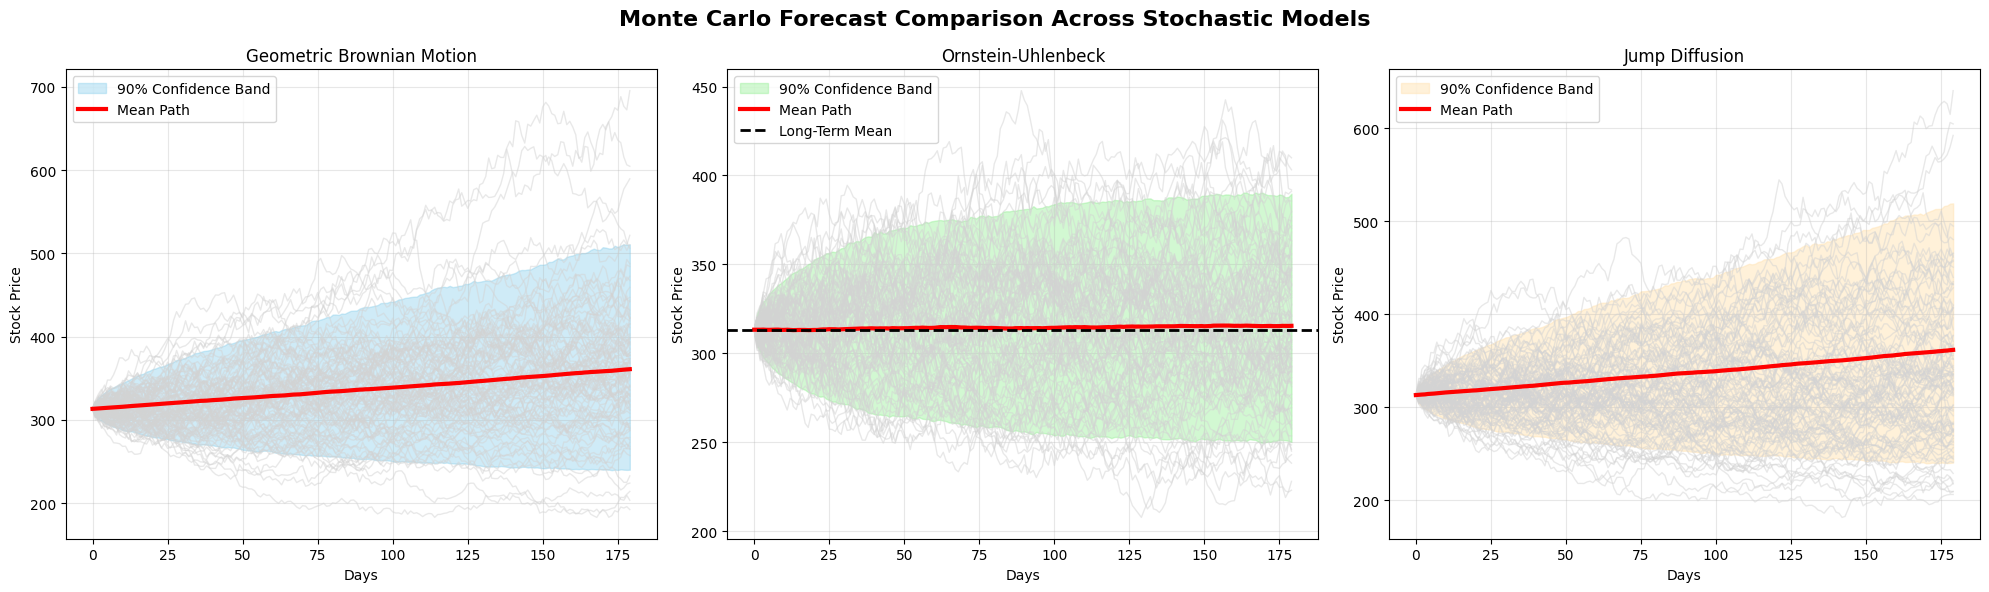

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Mean paths
gbm_mean = np.mean(gbm_paths, axis=1)
ou_mean = np.mean(ou_paths, axis=1)
jd_mean = np.mean(jd_paths, axis=1)

# ==================================================
# GBM
# ==================================================

for i in range(100):
    axes[0].plot(
        gbm_paths[:, i],
        color="lightgray",
        linewidth=1,
        alpha=0.5
    )

axes[0].fill_between(
    range(DAYS),
    np.percentile(gbm_paths, 5, axis=1),
    np.percentile(gbm_paths, 95, axis=1),
    color="skyblue",
    alpha=0.4,
    label="90% Confidence Band"
)

axes[0].plot(
    gbm_mean,
    color="red",
    linewidth=3,
    label="Mean Path"
)

axes[0].set_title("Geometric Brownian Motion")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Stock Price")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ==================================================
# OU
# ==================================================

for i in range(100):
    axes[1].plot(
        ou_paths[:, i],
        color="lightgray",
        linewidth=1,
        alpha=0.5
    )

axes[1].fill_between(
    range(DAYS),
    np.percentile(ou_paths, 5, axis=1),
    np.percentile(ou_paths, 95, axis=1),
    color="lightgreen",
    alpha=0.4,
    label="90% Confidence Band"
)

axes[1].plot(
    ou_mean,
    color="red",
    linewidth=3,
    label="Mean Path"
)

axes[1].axhline(
    y=S0,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Long-Term Mean"
)

axes[1].set_title("Ornstein-Uhlenbeck")
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Stock Price")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ==================================================
# JUMP DIFFUSION
# ==================================================

for i in range(100):
    axes[2].plot(
        jd_paths[:, i],
        color="lightgray",
        linewidth=1,
        alpha=0.5
    )

axes[2].fill_between(
    range(DAYS),
    np.percentile(jd_paths, 5, axis=1),
    np.percentile(jd_paths, 95, axis=1),
    color="moccasin",
    alpha=0.5,
    label="90% Confidence Band"
)

axes[2].plot(
    jd_mean,
    color="red",
    linewidth=3,
    label="Mean Path"
)

axes[2].set_title("Jump Diffusion")
axes[2].set_xlabel("Days")
axes[2].set_ylabel("Stock Price")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    "Monte Carlo Forecast Comparison Across Stochastic Models",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [65]:
SIMS = 5000
DAYS = 180

gbm_paths = gbm_simulation(
    S0=S0,
    mu=mu,
    sigma=sigma,
    days=DAYS,
    simulations=SIMS
)

print("Shape:", gbm_paths.shape)
print("Terminal prices:", len(gbm_final))

Shape: (180, 5000)
Terminal prices: 5000


**Terminal Price Histograms**

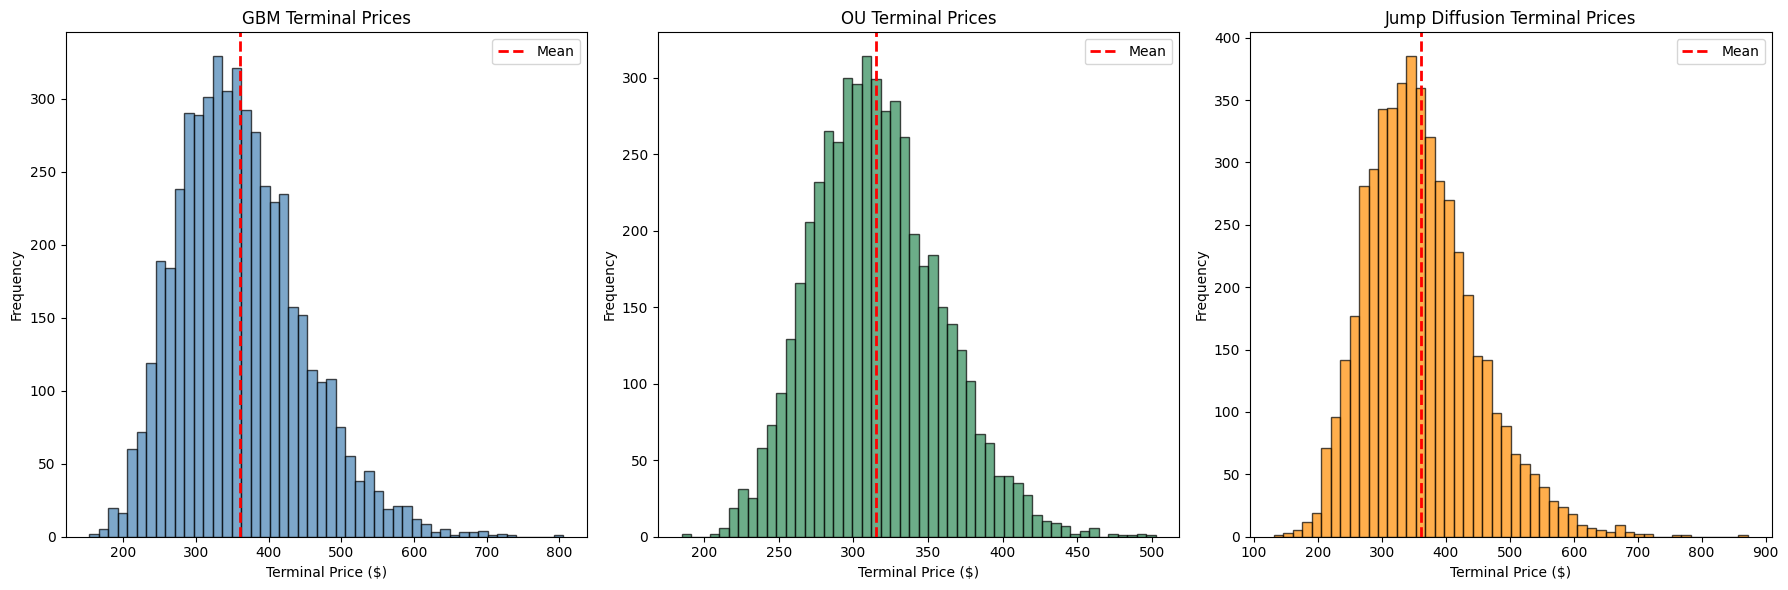

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

hist_data = [
    ("GBM", gbm_final, "steelblue"),
    ("OU", ou_final, "seagreen"),
    ("Jump Diffusion", jd_final, "darkorange")
]

for ax, (name, data, color) in zip(axes, hist_data):

    ax.hist(
        data,
        bins=50,
        color=color,
        alpha=0.7,
        edgecolor="black"
    )

    ax.axvline(
        np.mean(data),
        color="red",
        linestyle="--",
        linewidth=2,
        label="Mean"
    )

    ax.set_title(f"{name} Terminal Prices")
    ax.set_xlabel("Terminal Price ($)")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

**Multi-Assets Simulations**

In [67]:
# MULTI-ASSET GBM SIMULATION LOOP
future_prices = {}

for ticker in prices.columns:
    S0_ticker = float(prices[ticker].iloc[-1])
    ticker_returns = np.log(prices[ticker] / prices[ticker].shift(1)).dropna()

    mu_ticker = float(ticker_returns.mean()) * 252
    sigma_ticker = float(ticker_returns.std()) * np.sqrt(252)

    # Run GBM for the specific ticker
    paths = gbm_simulation(S0_ticker, mu_ticker, sigma_ticker, DAYS, SIMS)
    future_prices[ticker] = paths[-1]

# Compare the Value at Risk (VaR) across all three
print("95% 180-Day Value at Risk (VaR) by Asset:")
for ticker, final_prices in future_prices.items():
    S0_ticker = float(prices[ticker].iloc[-1])
    returns_sim = (final_prices - S0_ticker) / S0_ticker
    var_95 = np.percentile(returns_sim, 5)
    print(f"{ticker}: {var_95 * 100:.2f}%")

95% 180-Day Value at Risk (VaR) by Asset:
AAPL: -22.94%
MSFT: -26.45%
NVDA: -28.96%


# **Section 11: Confidence Intervals**

In [68]:
gbm_ci = np.percentile(gbm_final, [2.5, 97.5])
ou_ci = np.percentile(ou_final, [2.5, 97.5])
jd_ci = np.percentile(jd_final, [2.5, 97.5])

ci_table = pd.DataFrame({
    "Model":["GBM","OU","Jump Diffusion"],
    "Lower 95%":[gbm_ci[0], ou_ci[0], jd_ci[0]],
    "Upper 95%":[gbm_ci[1], ou_ci[1], jd_ci[1]]
})

display(ci_table.round(2))

,Model,Lower 95%,Upper 95%
0,GBM,223.35,549.10
1,OU,240.69,406.18
2,Jump Diffusion,222.67,556.71


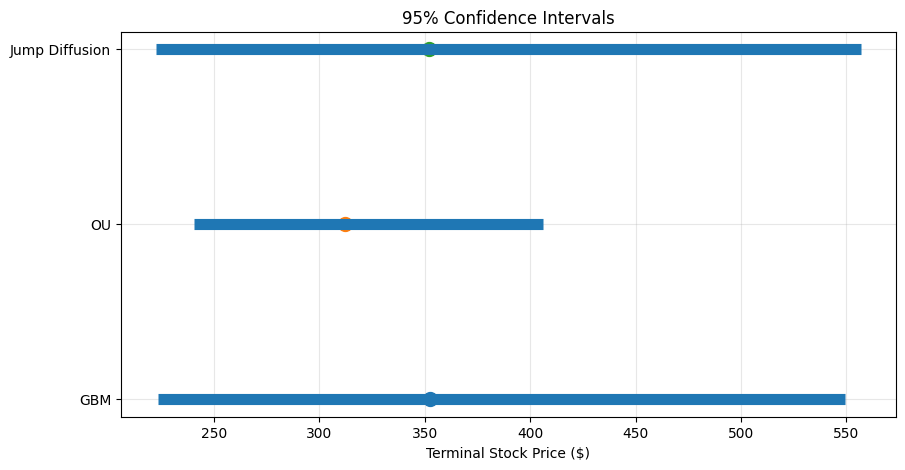

In [69]:
# ==================================================
# CONFIDENCE INTERVAL VISUALIZATION
# ==================================================

plt.figure(figsize=(10, 5))

models = ["GBM", "OU", "Jump Diffusion"]

for i, model in enumerate(models):

    if model == "GBM":
        lower, upper = gbm_ci
        center = np.median(gbm_final)

    elif model == "OU":
        lower, upper = ou_ci
        center = np.median(ou_final)

    else:
        lower, upper = jd_ci
        center = np.median(jd_final)

    plt.hlines(
        y=i,
        xmin=lower,
        xmax=upper,
        linewidth=8
    )

    plt.scatter(center, i, s=100)

plt.yticks(range(len(models)), models)

plt.title("95% Confidence Intervals")
plt.xlabel("Terminal Stock Price ($)")

plt.grid(True, alpha=0.3)
plt.show()

# **Section 12: Value at Risk (VaR) and Expected Shortfall**

In [70]:
# ==================================================
# VALUE AT RISK
# ==================================================

returns_gbm = (gbm_final / S0) - 1

VaR_95 = np.percentile(
    returns_gbm,
    5
)

print(f"95% VaR: {VaR_95:.4f}")

# ==================================================
# EXPECTED SHORTFALL
# ==================================================

tail_losses = returns_gbm[
    returns_gbm <= VaR_95
]

CVaR = tail_losses.mean()

print(f"95% CVaR: {CVaR:.4f}")

95% VaR: -0.2334
95% CVaR: -0.2996


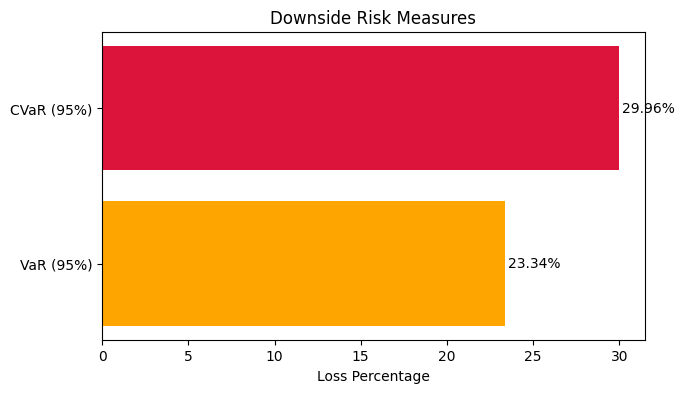

In [71]:
plt.figure(figsize=(7,4))

metrics = ["VaR (95%)", "CVaR (95%)"]

losses = [
    abs(VaR_95)*100,
    abs(CVaR)*100
]

bars = plt.barh(
    metrics,
    losses,
    color=["orange", "crimson"]
)

for bar in bars:

    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.2f}%",
        va="center"
    )

plt.xlabel("Loss Percentage")
plt.title("Downside Risk Measures")

plt.show()

In [72]:
print("GBM Mean:", gbm_final.mean())
print("OU Mean:", ou_final.mean())
print("JD Mean:", jd_final.mean())

GBM Mean: 360.8587954506113
OU Mean: 315.4042119071756
JD Mean: 361.7725023074886


# **Section 13: Model Comparison**

In [73]:
comparison = pd.DataFrame({
    "Model":[
        "GBM",
        "OU",
        "Jump Diffusion"
    ],

    "Mean Final Price":[
        gbm_final.mean(),
        ou_final.mean(),
        jd_final.mean()
    ],

    "Median Final Price":[
        np.median(gbm_final),
        np.median(ou_final),
        np.median(jd_final)
    ],

    "Std Dev":[
        gbm_final.std(),
        ou_final.std(),
        jd_final.std()
    ],

    "Probability of Loss (%)":[
        100*np.mean(gbm_final < S0),
        100*np.mean(ou_final < S0),
        100*np.mean(jd_final < S0)
    ]
})

display(comparison.round(2))

,Model,Mean Final Price,Median Final Price,Std Dev,Probability of Loss (%)
0,GBM,360.86,352.35,84.15,30.98
1,OU,315.40,312.35,42.45,50.74
2,Jump Diffusion,361.77,352.11,85.57,30.96


Mean Price Comparison Chart

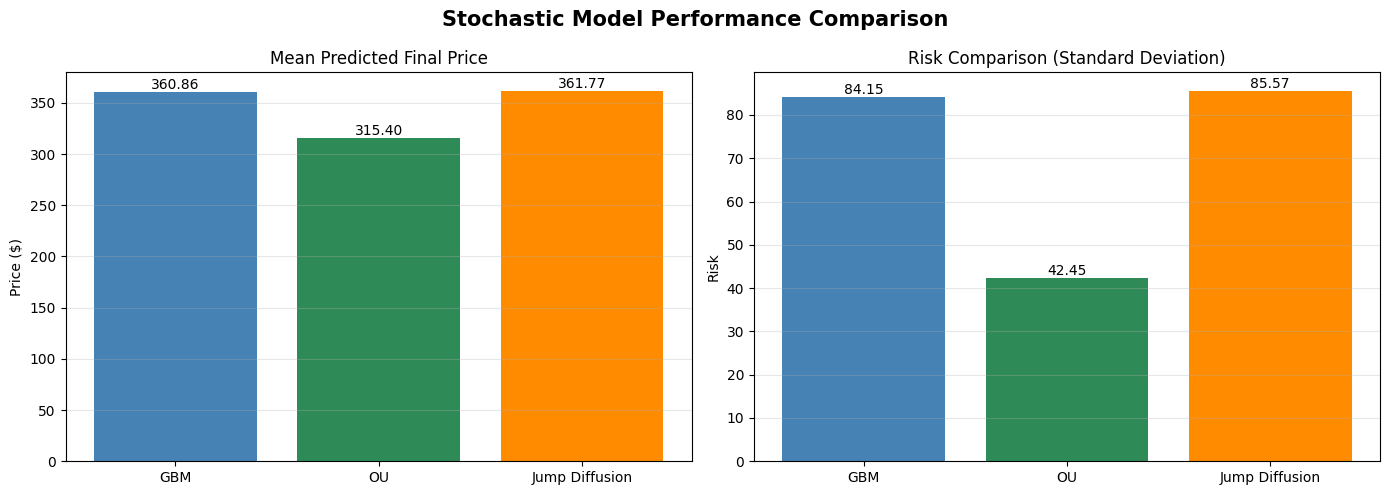

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean Price Plot
bars1 = axes[0].bar(
    comparison["Model"],
    comparison["Mean Final Price"],
    color=["steelblue", "seagreen", "darkorange"]
)

axes[0].set_title("Mean Predicted Final Price")
axes[0].set_ylabel("Price ($)")
axes[0].grid(axis="y", alpha=0.3)

for bar in bars1:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{h:.2f}",
        ha="center",
        va="bottom"
    )

# Risk Plot
bars2 = axes[1].bar(
    comparison["Model"],
    comparison["Std Dev"],
    color=["steelblue", "seagreen", "darkorange"]
)

axes[1].set_title("Risk Comparison (Standard Deviation)")
axes[1].set_ylabel("Risk")
axes[1].grid(axis="y", alpha=0.3)

for bar in bars2:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{h:.2f}",
        ha="center",
        va="bottom"
    )

plt.suptitle(
    "Stochastic Model Performance Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Comparative Fan Charts**

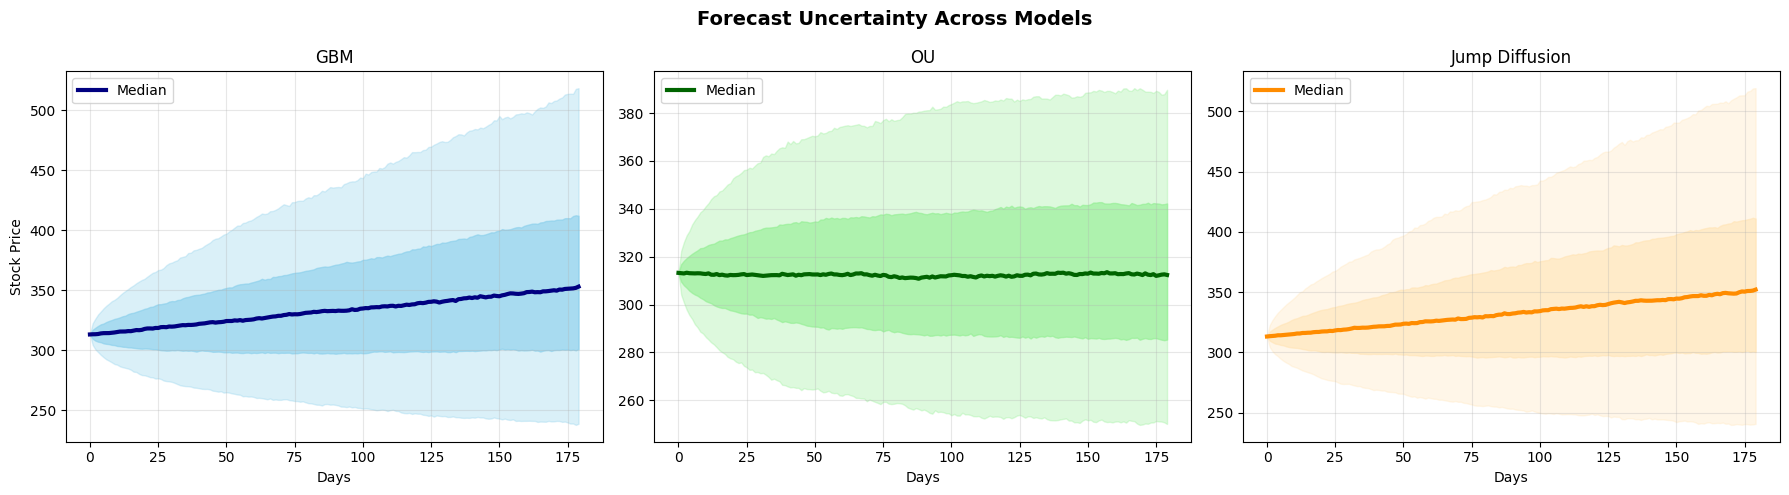

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("GBM", gbm_paths, "skyblue", "navy"),
    ("OU", ou_paths, "lightgreen", "darkgreen"),
    ("Jump Diffusion", jd_paths, "moccasin", "darkorange")
]

for ax, (title, paths, fill_color, line_color) in zip(axes, models):

    percentiles = np.percentile(
        paths,
        [5, 25, 50, 75, 95],
        axis=1
    )

    days = np.arange(paths.shape[0])

    # 90% confidence band
    ax.fill_between(
        days,
        percentiles[0],
        percentiles[4],
        color=fill_color,
        alpha=0.3
    )

    # 50% confidence band
    ax.fill_between(
        days,
        percentiles[1],
        percentiles[3],
        color=fill_color,
        alpha=0.6
    )

    # Median path
    ax.plot(
        days,
        percentiles[2],
        color=line_color,
        linewidth=3,
        label="Median"
    )

    ax.set_title(title)
    ax.set_xlabel("Days")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Stock Price")

plt.suptitle(
    "Forecast Uncertainty Across Models",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# **Section 14: Analysis & Interpretation**

Key findings from the simulations include:

- GBM produced the widest range of future prices.
- OU displayed clear mean-reverting behavior and lower dispersion.
- Jump Diffusion captured extreme market shocks and tail-risk events.
- Confidence intervals widened as forecast horizons increased.
- Jump Diffusion exhibited heavier tails than GBM.
- VaR and CVaR highlighted meaningful downside risk.

Overall, GBM generated the highest growth potential, while OU produced the most stable forecasts.